# Cross Frequency Coupling

In [1]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import matplotlib.pyplot as plt
from utils import OUT_PATH, GetInfo, ExcludSubj, FREQ_BAND, EVENT_ID

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
print(f"Subject Nbr is {len(subj_included)}")

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_tfr=d['time_tfr']
     
coord, areas, elect_list, subj_list, regions = GetInfo(subj_included, data_path=tfr_path)

Subject Nbr is 30


In [2]:
from scipy.signal import hilbert, butter, sosfiltfilt

def bandpass(data: np.ndarray, edges: list[float], sample_rate: float, poles: int = 5):
    sos = butter(poles, edges, 'bandpass', fs=sample_rate, output='sos')
    filtered_data = sosfiltfilt(sos, data)
    return filtered_data

## Signal inspection type of waves

In [31]:
spl_rate = 200
bands = ['theta', 'high_gamma']
param_filter = {'delta' : [0, 4], 'theta': [4, 8], 'high_gamma': [55, 99]}
tr_band_analog_ = {}
for subj in np.unique(subj_list)[:1] :
    
    file = tfr_path + f'/{subj}_epochs.p'
    with open(file, "rb") as f:
        epoch = pickle.load(f)
    info_file = tfr_path + f'/{subj}_info.json'
    with open(info_file) as f:
        info = json.load(f)
        events_index = np.array([int(i) for i in info['event_id']])

    for ev in ['old/correct'] : #, 'new/correct'] : 
        id_ev = np.where(events_index == EVENT_ID[ev])[0]
        tr_band = epoch[np.ix_(id_ev, range(epoch.shape[1]), range(epoch.shape[-1]))]

        for band in bands : 
            tr_band_analog = np.zeros(tr_band.shape)
            for c in range(tr_band.shape[1]) : 
                for e in range(tr_band.shape[0]) :
                    analog = hilbert(bandpass(tr_band[e, c,:], param_filter[band], spl_rate))
                    tr_band_analog[e, c, :] = analog
            tr_band_analog_[band] = tr_band_analog

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_6014/751525034.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  tr_band_analog[e, c, :] = analog


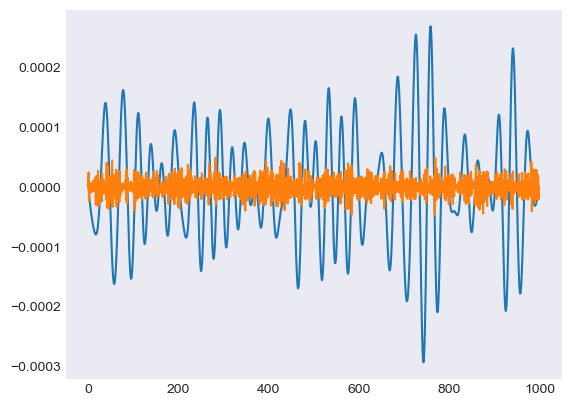

In [32]:
plt.plot(tr_band_analog_['theta'][:, 0, :].mean(0))
plt.plot(tr_band_analog_['high_gamma'][:, 0, :].mean(0))


## PAC

In [18]:
# Select the electrods involved in the network of interest
band1 = 'theta'
pc1 ='compo1'
band2 = 'high_gamma'
pc2 = 'compo3'
weight1 = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band1 & compo == @pc1').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]
weight2 = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band2 & compo == @pc2').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]

data = pd.DataFrame()
data['ch1'] = np.where(abs(weight1) > abs(weight1).mean() + abs(weight1).std(), True, False)
data['ch2'] = np.where(abs(weight2) > abs(weight2).mean() + abs(weight2).std(), True, False)
data['subj'] = subj_list
data['ROIs'] = regions

In [19]:
trials = {band1 + '_old/correct' : [], band2 + '_old/correct' : [], band1 + '_new/correct':[], band2 + '_new/correct':[]}
spl_rate = 200
param_filter={'theta' : [4, 8], 'high_gamma' : [55, 99]}

for subj in np.unique(subj_list) :
    data_subj = data.query('subj == @subj').reset_index()
    ch1 = data_subj.query("ch1 == True").index
    ch2 = data_subj.query("ch2 == True").index
    ch_all = {band1 : ch1, band2 : ch2}

    if len(ch1) == 0 and len(ch2) == 0 : 
        continue
    else : 
        file = tfr_path + f'/{subj}_epochs.p'
        with open(file, "rb") as f:
            epoch = pickle.load(f)
        info_file = tfr_path + f'/{subj}_info.json'
        with open(info_file) as f:
            info = json.load(f)
            events_index = np.array([int(i) for i in info['event_id']])

        for ev in ['old/correct', 'new/correct'] : 
            id_ev = np.where(events_index == EVENT_ID[ev])[0]
            for band in [band1, band2]:
                id_ch = np.array(ch_all[band])
                if len(id_ch) == 0 : 
                    continue
                tr_band = epoch[np.ix_(id_ev, id_ch, range(epoch.shape[-1]))]
                # filtering + hilbert transform + ampl and angle
                tr_band_env = np.zeros_like(tr_band)
                tr_band_phase = np.zeros_like(tr_band)
                for c in range(tr_band.shape[1]) : 
                    for e in range(tr_band.shape[0]) :
                        analog = hilbert(bandpass(tr_band[e, c,:], param_filter[band], spl_rate))
                        tr_band_env[e, c, :] = abs(analog)
                        tr_band_phase[e, c, :] = np.angle(analog) 

                trials[band + '_' + ev].append({'env' : tr_band_env, 'phase' : tr_band_phase})

In [20]:
hg_env = []
th_phase =[] 
th_env=[]
ev = 'old/correct'
for tr in trials['high_gamma' + '_' + ev] : 
    hg_env.extend([tr['env'][:,c, :] for c in range(tr['env'].shape[1])])

for tr in trials['theta' + '_' + ev] : 
    th_phase.extend([tr['phase'][:,c, :] for c in range(tr['phase'].shape[1])])
    th_env.extend([tr['env'][:,c, :] for c in range(tr['env'].shape[1])])


/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_6014/277930346.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  gh_index_ROIs = data[data['ch2'] == True].reset_index()[data['ROIs'] == 'HPC'].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_6014/277930346.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  th_index_ROIs = data[data['ch1'] == True].reset_index()[data['ROIs'] == 'HPC'].index.values


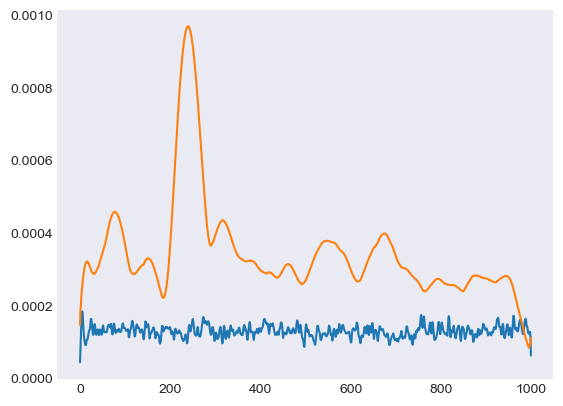

In [21]:
gh_index_ROIs = data[data['ch2'] == True].reset_index()[data['ROIs'] == 'HPC'].index.values
th_index_ROIs = data[data['ch1'] == True].reset_index()[data['ROIs'] == 'HPC'].index.values

plt.plot(hg_env[gh_index_ROIs[0]].mean(0))
plt.plot(th_env[th_index_ROIs[0]].mean(0))


In [37]:
len(edges)

15

In [ ]:
edges = np.linspace(-np.pi, np.pi, 19)
Mi = {}
best_phase = {}
for ith, ch_th in enumerate(th_phase) : 
        for igh, ch_gh in enumerate(hg_env) : 
                Mi_all = []
                # trials in commun 
                nb_trials = np.min([ch_th.shape[0], ch_gh.shape[0]])
                mi_tr= []
                pj_list=[]
                for tr in range(nb_trials) :
                        th_ = ch_th[tr,:]
                        gh_ = ch_gh[tr,:]

                        bin_idx_theta = np.digitize(th_, edges) - 1
                        hg_mean_ampl = []
                        for k in range(len(edges)-1):
                                indices = np.where(bin_idx_theta == k)[0]
                                hg_mean_ampl.append(np.mean(gh_[indices]))

                        pj = [val/np.sum(hg_mean_ampl) for val in hg_mean_ampl]
                        H_p = - np.sum(pj * np.log(pj))
                        H_max = np.log(len(edges)-1)
                        mi= (H_max - H_p)/H_max
                        mi_tr.append(mi)
                        pj_list.append(pj.index(np.max(pj)))
                        
                best_phase[(ith, igh)] = pj_list
                Mi[(ith, igh)] = mi_tr
        

In [77]:
mi_mean =np.zeros([len(th_phase), len(hg_env)])
mi_std =np.zeros([len(th_phase), len(hg_env)])
pref_phase = np.zeros([len(th_phase), len(hg_env)])
pref_count = np.zeros([len(th_phase), len(hg_env)])

for i in range(len(th_phase)) : 
    for j in range(len(hg_env)) : 
        u, c= np.unique(best_phase[(i, j)], return_counts=True)
        pref_phase[i, j] = u[c.argmax()]
        pref_count[i, j] =  c.argmax()
        mi_mean[i, j] = np.mean(Mi[(i, j)])
        mi_std[i, j] = np.std(Mi[(i, j)])

In [80]:
data_ = data #.set_index('subj').loc[np.unique(subj_list)[:15], :].reset_index()
data_th = data_[data_['ch1'] == True]['ROIs'].values
data_gh = data_[data_['ch2'] == True]['ROIs'].values

Text(0.5, 32.17708333333332, 'High gamma channels invovled in Net1')

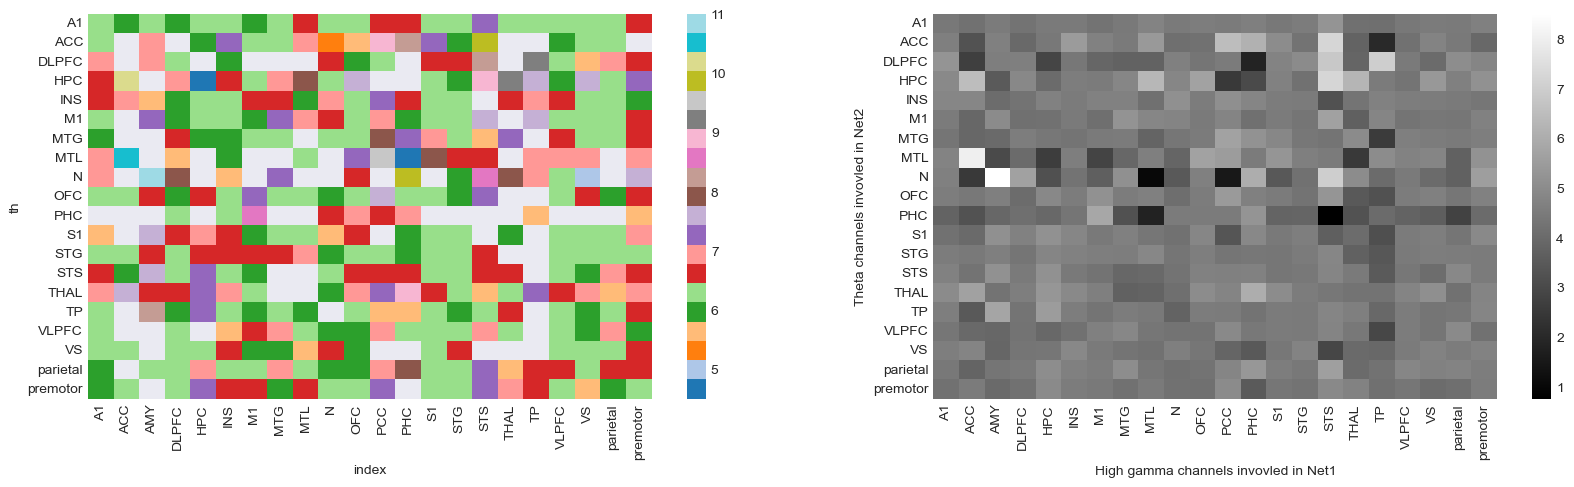

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
pref_phase_df = pd.DataFrame(pref_phase, columns = data_gh)
pref_phase_df['th'] = data_th
pref_phase_df= pref_phase_df.set_index('th')
pref_phase_df = pref_phase_df.reset_index().groupby('th').mean().T.reset_index().groupby('index').mean().T

sns.heatmap(pref_phase_df, cmap='tab20', ax=ax[0], mask=np.where(pref_count_df.values<4, True, False))
plt.ylabel('Theta channels invovled in Net2')
plt.xlabel('High gamma channels invovled in Net1')

pref_count_df = pd.DataFrame(pref_count, columns = data_gh)
pref_count_df['th'] = data_th
pref_count_df= pref_count_df.set_index('th')
pref_count_df = pref_count_df.reset_index().groupby('th').mean().T.reset_index().groupby('index').mean().T

sns.heatmap(pref_count_df, cmap='grey', ax=ax[1])
plt.ylabel('Theta channels invovled in Net2')
plt.xlabel('High gamma channels invovled in Net1')

In [25]:
df_mean_mi = pd.DataFrame(mi_mean, columns = data_gh)


In [26]:
df_mean_mi['th'] = data_th
df_mean_mi= df_mean_mi.set_index('th')
df_mean =df_mean_mi.sort_index().T.sort_index().T

Text(0.5, 29.977083333333326, 'High gamma channels invovled in Net1')

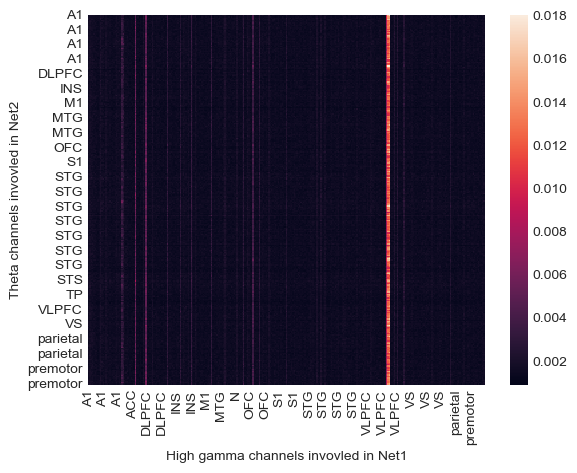

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_mean)
plt.ylabel('Theta channels invovled in Net2')
plt.xlabel('High gamma channels invovled in Net1')

Text(0.5, 29.977083333333326, 'High gamma channels invovled in Net3')

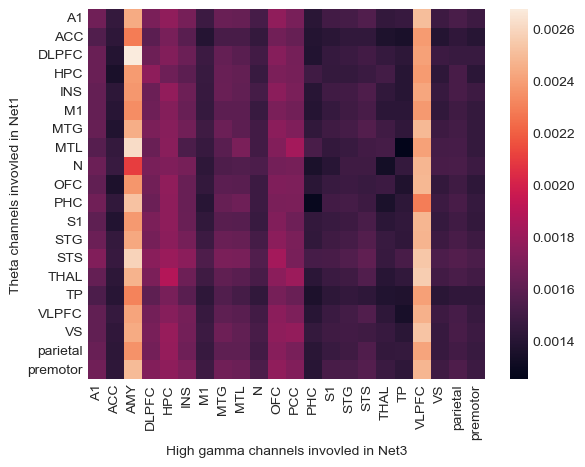

In [28]:
df_mean_mean = df_mean_mi.reset_index().groupby('th').mean().T.reset_index().groupby('index').mean().T
sns.heatmap(df_mean_mean)
plt.ylabel('Theta channels invovled in Net1')
plt.xlabel('High gamma channels invovled in Net3')

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4155/3743890413.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hg_index_ROIs = data[data['ch2'] == True].reset_index()[data['ROIs'] == roi2].index
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4155/3743890413.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  th_index_ROIs = data[data['ch1'] == True].reset_index()[data['ROIs'] == roi1].index


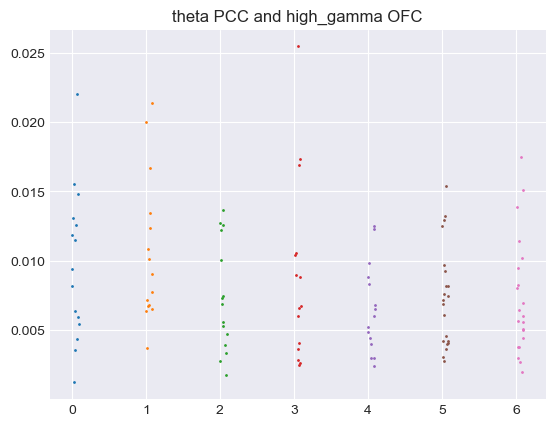

In [173]:
roi1 = 'PCC'
roi2 = 'OFC'
hg_index_ROIs = data[data['ch2'] == True].reset_index()[data['ROIs'] == roi2].index
th_index_ROIs = data[data['ch1'] == True].reset_index()[data['ROIs'] == roi1].index

MI_rois = []
for id_th in th_index_ROIs:
    for id_hg in hg_index_ROIs :
        MI_rois.append(Mi[(id_th, id_hg)])

for cp_i, cp in enumerate(MI_rois) : 
    plt.scatter(cp_i + np.random.uniform(high=0.1, size=len(cp)), cp, s=1)
plt.title(f'{band1} {roi1} and {band2} {roi2}')
plt.grid()